# 03 — Earth Observation: cloud-fraction distribution and the OPERA gap

The single most consequential finding of Phase 1. Decides how much optical imagery
is usable at all, and why the trigger design changed from the brief's original spec.

In [1]:
import sys
sys.path.insert(0, "..")
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

dist = json.loads(Path("../dist/sentinel2_cloud_distribution.json").read_text())
by_month = pd.DataFrame(dist["by_month"]).T
by_month.index = by_month.index.astype(int)
by_month = by_month.sort_index()
by_month

,n,median,usable_under_20
1,233.0,20.991959,115.0
2,235.0,13.741808,135.0
3,282.0,17.405462,148.0
4,273.0,29.619738,116.0
5,266.0,54.566232,43.0
6,276.0,61.835235,20.0
7,276.0,80.159607,1.0
8,299.0,75.022489,6.0
9,237.0,64.053404,14.0
10,252.0,30.338220,97.0


## Median cloud cover by month, 2016–2026, over the corridor

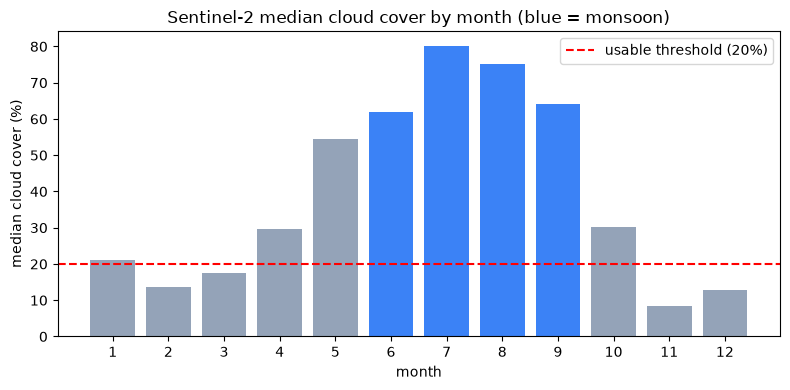

total scenes analysed: 3126
scenes under 20% cloud: 993 (31.8%)

monsoon months (Jun-Sep): 1088.0 scenes, 41.0 usable (<20% cloud) = 3.8%


In [2]:
fig, ax = plt.subplots(figsize=(8, 4))
months = by_month.index
colors = ["#3b82f6" if 6 <= m <= 9 else "#94a3b8" for m in months]
ax.bar(months, by_month["median"], color=colors)
ax.set_xticks(range(1, 13))
ax.set_xlabel("month")
ax.set_ylabel("median cloud cover (%)")
ax.set_title("Sentinel-2 median cloud cover by month (blue = monsoon)")
ax.axhline(20, color="red", ls="--", label="usable threshold (20%)")
ax.legend()
plt.tight_layout()
plt.savefig("../dist/cloud_by_month.png", dpi=100)
plt.show()

print(f"total scenes analysed: {dist['scenes']}")
print(f"scenes under 20% cloud: {dist['under_20pct']} ({dist['under_20pct_frac']*100:.1f}%)")
monsoon = by_month.loc[[6,7,8,9]]
print(f"\nmonsoon months (Jun-Sep): {monsoon['n'].sum()} scenes, "
      f"{monsoon['usable_under_20'].sum()} usable (<20% cloud) "
      f"= {monsoon['usable_under_20'].sum()/monsoon['n'].sum()*100:.1f}%")

**Both fatal events in this corridor happened during the monsoon** — 8 July 2025
and 26 August 2026. Optical imagery is usable roughly 4% of the time in exactly the
window that matters. This is not a preference for radar; it is the only option.

## The OPERA processing gap

In [3]:
from core.connectors.opera import login, search, granule_dates
login()
bbox = (85.10, 27.80, 85.45, 28.55)

for name, temporal in [
    ("OPERA_L3_DSWX-S1_V1", ("2026-01-01", "2026-09-03")),
    ("OPERA_L3_DIST-ALERT-HLS_V1", ("2026-07-01", "2026-09-03")),
]:
    r = search(name, bbox, temporal)
    dates = granule_dates(r)
    print(f"{name:32} {len(r):4} granules, last date {dates[-1] if dates else 'none'}")

/home/trishan/Work/TSN-Hackathon/.venv/lib/python3.12/site-packages/earthaccess/results.py:348: FutureWarning: As of version 1.0, `DataGranule.size` will be accessed as an attribute; e.g. use `DataCollection.size` **not** `DataCollection.size()`
  self["size"] = self.size()


OPERA_L3_DSWX-S1_V1               135 granules, last date 20260625


OPERA_L3_DIST-ALERT-HLS_V1         56 granules, last date 20260901


**OPERA DSWx-S1 — the brief's stated trigger — has no granules over this corridor
after 25 June 2026.** Sentinel-1 GRD acquisitions continue through 31 August (verified
in the Planetary Computer STAC catalogue). The gap is in OPERA's Sentinel-1 processing
pipeline, not in satellite coverage.

**Design consequence, recorded in `PROGRESS.md`:** DIST-ALERT-HLS v1 becomes the live
trigger (it is current), and our own Sentinel-1 RTC water detector — sourced directly
from Planetary Computer, terrain-corrected, already in EPSG:32645 — carries water
detection for the event window. This is the 'degrade, don't die' property arriving
during the build rather than during the demo.

## Sentinel-1 RTC coverage of the event window

In [4]:
from core.connectors.stac import search_items, item_summary
items = search_items("sentinel-1-rtc", bbox, "2026-07-01/2026-09-03")
df = pd.DataFrame(item_summary(items))
df

,id,datetime,cloud_cover,orbit_state,platform
0,S1D_IW_GRDH_1SDV_20260702T001034_20260702T0010...,2026-07-02T00:10:46.978937+00:00,None,descending,sentinel-1d
1,S1D_IW_GRDH_1SDV_20260707T001841_20260707T0019...,2026-07-07T00:18:54.460854+00:00,None,descending,sentinel-1d
2,S1D_IW_GRDH_1SDV_20260711T122139_20260711T1222...,2026-07-11T12:21:51.656663+00:00,None,ascending,sentinel-1d
3,S1D_IW_GRDH_1SDV_20260714T001035_20260714T0011...,2026-07-14T00:10:47.765435+00:00,None,descending,sentinel-1d
4,S1D_IW_GRDH_1SDV_20260719T001842_20260719T0019...,2026-07-19T00:18:55.400207+00:00,None,descending,sentinel-1d
5,S1D_IW_GRDH_1SDV_20260723T122140_20260723T1222...,2026-07-23T12:21:52.612691+00:00,None,ascending,sentinel-1d
6,S1D_IW_GRDH_1SDV_20260726T001036_20260726T0011...,2026-07-26T00:10:48.609903+00:00,None,descending,sentinel-1d
7,S1D_IW_GRDH_1SDV_20260731T001843_20260731T0019...,2026-07-31T00:18:55.939263+00:00,None,descending,sentinel-1d
8,S1D_IW_GRDH_1SDV_20260804T122140_20260804T1222...,2026-08-04T12:21:52.992465+00:00,None,ascending,sentinel-1d
9,S1D_IW_GRDH_1SDV_20260807T001036_20260807T0011...,2026-08-07T00:10:48.957629+00:00,None,descending,sentinel-1d


**A matched-geometry before/after pair exists: 16 Aug (ascending) vs 28 Aug (ascending).**